# Coffee Dialling Automation — Regression Model
# Version 2  
## Cleaned Regression Approach with Positive Cross-Validation Results

**Approach:** Supervised Regression Modelling  
**Target Variable:** `Overall`  
**Main Model:** Random Forest Regressor  
**Dataset:** CQI Arabica Coffee Quality Dataset  

---

## Important Version 2 Context

Version 2 does not reuse the failure interpretation from Version 1.

The purpose of this version is to explain why the cleaned workflow produces more stable and positive cross-validation results.

The key improvement is:

```python
KFold(n_splits=5, shuffle=True, random_state=42)
```

This creates more balanced folds and avoids the unshuffled fold problem seen in Version 1.


# 0. Workflow Overview

Version 2 follows this improved workflow:

1. Load the CQI Arabica dataset.
2. Rename and standardise key columns.
3. Select regression features and target.
4. Clean missing values and unrealistic values.
5. Group categorical features carefully.
6. Separate numerical and categorical features.
7. Build a preprocessing pipeline.
8. Train a Random Forest Regressor inside a pipeline.
9. Evaluate the model using a single train-test split.
10. Evaluate again using shuffled 5-fold cross-validation.
11. Compare regression models using the same shuffled CV strategy.
12. Interpret results based on Version 2's improved validation setup.
13. Export report-ready files.

This version supports the final regression story because it applies a cleaner and more defensible modelling process.

# 1. Import Required Libraries

These libraries are used for data handling, visualisation, preprocessing, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


# 2. Load the Dataset

The dataset used is the CQI Arabica coffee quality dataset.  
The file may be uploaded manually into Google Colab or stored in the same directory as this notebook.

The dataset uses a non-standard encoding, so an encoding fallback is used to avoid loading errors.

In [2]:
# Load dataset with encoding fallback
file_path = "Arabica.csv"

try:
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (207, 37)


,ID,Country/Region of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,...,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration
0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,...,10,8.58,0,89.33,11.8,0,0,green,3,"September 21st, 2023"
1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,?????????,...,10,8.50,0,87.58,10.5,0,0,blue-green,0,"November 15th, 2023"
2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,...,10,8.33,0,87.42,10.4,0,0,yellowish,2,"November 15th, 2023"
3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,...,10,8.25,0,87.17,11.8,0,0,green,0,"September 21st, 2023"
4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,...,10,8.25,0,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024"


## 2.1 Dataset Overview

This quick overview confirms the number of rows, columns, data types, and missing values.  
It helps identify whether the dataset is ready for modelling or requires preprocessing.

In [4]:
print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

print("Missing values summary:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

display(df.describe(include='all').T.head(20))

Dataset shape: (207, 37)
Column names:
['ID', 'Country/Region of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration']
Missing values summary:


,0
ICO Number,132
Variety,6
Processing Method,5
Mill,3
Farm Name,2
Region,2
Altitude,1
Lot Number,1
Producer,1
Country/Region of Origin,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,207.0,NaN,NaN,NaN,103.0,59.899917,0.0,51.5,103.0,154.5,206.0
Country/Region of Origin,207,22,Taiwan,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm Name,205,144,??????????????????,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Number,206,187,1,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mill,204,133,Dry Mill,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICO Number,75,67,non,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,207,72,Taiwan Coffee Laboratory,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Altitude,206,97,1200,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,205,116,?????????,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Producer,206,128,?????????,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Feature Selection

The regression target is **`Overall`**, which represents the Q-Grader's holistic quality judgement.

## Features selected

The selected features include:

### Sensory features
- Aroma
- Flavor
- Aftertaste
- Acidity
- Body
- Balance

### Physical / quality control features
- Moisture Percentage
- Altitude
- Category One Defects
- Category Two Defects

### Categorical features
- Country/Region of Origin
- Processing Method

## Features excluded

- `Total Cup Points` was excluded because it is a direct sum of sensory scores and would create data leakage.
- Administrative columns such as farm name, owner, lot number, and ICO number were excluded because they do not provide generalisable predictive value.
- Constant or near-constant sensory columns such as Uniformity, Clean Cup, and Sweetness were excluded because they provide little or no variance.

In [5]:
# Define selected columns
selected_columns = [
    'Country/Region of Origin',
    'Altitude',
    'Processing Method',
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Moisture Percentage',
    'Category One Defects',
    'Category Two Defects',
    'Overall'
]

regression_df = df[selected_columns].copy()

print("Regression dataframe shape:", regression_df.shape)
display(regression_df.head())

Regression dataframe shape: (207, 13)


,Country/Region of Origin,Altitude,Processing Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture Percentage,Category One Defects,Category Two Defects,Overall
0,Colombia,1700-1930,Double Anaerobic Washed,8.58,8.50,8.42,8.58,8.25,8.42,11.8,0,3,8.58
1,Taiwan,1200,Washed / Wet,8.50,8.50,7.92,8.00,7.92,8.25,10.5,0,0,8.50
2,Laos,1300,Semi Washed,8.33,8.42,8.08,8.17,7.92,8.17,10.4,0,2,8.33
3,Costa Rica,1900,Washed / Wet,8.08,8.17,8.17,8.25,8.17,8.08,11.8,0,0,8.25
4,Colombia,1850-2100,"Honey,Mossto",8.33,8.33,8.08,8.25,7.92,7.92,11.6,0,2,8.25


# 4. Data Cleaning and Preprocessing

The raw dataset includes mixed formats and inconsistent categorical values.  
The following steps clean the data before modelling:

1. Clean altitude values into numeric format  
2. Replace impossible moisture values  
3. Simplify processing methods  
4. Group rare countries  
5. Handle missing values

## 4.1 Clean Altitude Values

The `Altitude` column contains values such as single numbers, ranges, and text-based entries.  
For modelling, the altitude must be converted into a numeric feature.

When a range is present, the average of the range is used.

In [6]:
import re

def clean_altitude(value):
    if pd.isna(value):
        return np.nan

    value = str(value).replace(',', '').lower()
    numbers = re.findall(r'\d+\.?\d*', value)

    if len(numbers) == 0:
        return np.nan
    elif len(numbers) == 1:
        return float(numbers[0])
    else:
        nums = [float(n) for n in numbers]
        return sum(nums) / len(nums)

regression_df['Altitude Clean'] = regression_df['Altitude'].apply(clean_altitude)

print("Altitude cleaning completed")
display(regression_df[['Altitude', 'Altitude Clean']].head(10))

Altitude cleaning completed


,Altitude,Altitude Clean
0,1700-1930,1815.0
1,1200,1200.0
2,1300,1300.0
3,1900,1900.0
4,1850-2100,1975.0
5,1668,1668.0
6,1250,1250.0
7,1200,1200.0
8,1250,1250.0
9,1400-1700,1550.0


## 4.2 Treat Unrealistic Altitude Values

Some altitude values are unrealistically high for coffee cultivation and are likely data entry issues.  
Values above 4000 metres are replaced with the median altitude from valid entries.

In [7]:
valid_altitude_median = regression_df.loc[
    regression_df['Altitude Clean'].between(100, 4000),
    'Altitude Clean'
].median()

outlier_altitude_count = (regression_df['Altitude Clean'] > 4000).sum()

regression_df.loc[regression_df['Altitude Clean'] > 4000, 'Altitude Clean'] = valid_altitude_median
regression_df['Altitude Clean'] = regression_df['Altitude Clean'].fillna(valid_altitude_median)

print("Altitude outliers replaced:", outlier_altitude_count)
print("Median altitude used:", round(valid_altitude_median, 2))
print("Final altitude range:", regression_df['Altitude Clean'].min(), "to", regression_df['Altitude Clean'].max())

Altitude outliers replaced: 4
Median altitude used: 1300.0
Final altitude range: 139.0 to 2361.0


## 4.3 Treat Invalid Moisture Percentage Values

A moisture value of 0% is physically unrealistic for coffee beans and is treated as a data error.  
Invalid zero values are replaced with the median of valid moisture values.

In [8]:
valid_moisture_median = regression_df.loc[
    regression_df['Moisture Percentage'] > 0,
    'Moisture Percentage'
].median()

zero_moisture_count = (regression_df['Moisture Percentage'] == 0).sum()

regression_df.loc[regression_df['Moisture Percentage'] == 0, 'Moisture Percentage'] = valid_moisture_median

print("Zero moisture values replaced:", zero_moisture_count)
print("Median moisture used:", round(valid_moisture_median, 2))

Zero moisture values replaced: 1
Median moisture used: 10.85


## 4.4 Simplify Processing Methods

The raw `Processing Method` column contains multiple rare and inconsistent categories.  
These are grouped into broader categories to reduce sparsity and improve model stability.

In [9]:
def simplify_processing(value):
    if pd.isna(value):
        return 'Other'

    value = str(value).lower()

    if 'washed' in value or 'wet' in value or 'lavado' in value or 'hulling' in value:
        return 'Washed'
    elif 'natural' in value or 'dry' in value:
        return 'Natural'
    elif 'honey' in value or 'pulped' in value or 'mossto' in value:
        return 'Honey'
    else:
        return 'Other'

regression_df['Processing Simple'] = regression_df['Processing Method'].apply(simplify_processing)

print("Processing method categories:")
display(regression_df['Processing Simple'].value_counts())

Processing method categories:


,count
Processing Simple,
Washed,128
Natural,72
Other,6
Honey,1


## 4.5 Group Rare Countries

Countries with very few samples create sparse one-hot encoded columns and increase overfitting risk.  
Countries with fewer than 5 samples are grouped into `Other`.

In [11]:
country_counts = regression_df['Country/Region of Origin'].value_counts()
rare_countries = country_counts[country_counts < 5].index

regression_df['Country Grouped'] = regression_df['Country/Region of Origin'].replace(rare_countries, 'Other')

print("Rare countries grouped into 'Other':")
print(list(rare_countries))

print("Grouped country counts:")
display(regression_df['Country Grouped'].value_counts())

Rare countries grouped into 'Other':
['Mexico', 'Peru', 'Vietnam', 'Laos', 'Uganda', 'Indonesia', 'Kenya', 'Panama', 'Madagascar', 'Myanmar']
Grouped country counts:


,count
Country Grouped,
Taiwan,61
Other,27
Guatemala,21
Colombia,19
Honduras,13
Thailand,12
Ethiopia,11
Brazil,10
Costa Rica,8


# 5. Final Modelling Dataset

The final modelling dataset contains cleaned numeric features, simplified categorical features, and the target variable `Overall`.

In [13]:
final_features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Moisture Percentage',
    'Altitude Clean',
    'Category One Defects',
    'Category Two Defects',
    'Country Grouped',
    'Processing Simple'
]

target = 'Overall'

model_df = regression_df[final_features + [target]].copy()

print("Final modelling dataset shape:", model_df.shape)
display(model_df.head())

print("Missing values in final dataset:")
display(model_df.isnull().sum())

Final modelling dataset shape: (207, 13)


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture Percentage,Altitude Clean,Category One Defects,Category Two Defects,Country Grouped,Processing Simple,Overall
0,8.58,8.50,8.42,8.58,8.25,8.42,11.8,1815.0,0,3,Colombia,Washed,8.58
1,8.50,8.50,7.92,8.00,7.92,8.25,10.5,1200.0,0,0,Taiwan,Washed,8.50
2,8.33,8.42,8.08,8.17,7.92,8.17,10.4,1300.0,0,2,Other,Washed,8.33
3,8.08,8.17,8.17,8.25,8.17,8.08,11.8,1900.0,0,0,Costa Rica,Washed,8.25
4,8.33,8.33,8.08,8.25,7.92,7.92,11.6,1975.0,0,2,Colombia,Honey,8.25


Missing values in final dataset:


,0
Aroma,0
Flavor,0
Aftertaste,0
Acidity,0
Body,0
Balance,0
Moisture Percentage,0
Altitude Clean,0
Category One Defects,0
Category Two Defects,0


# 6. Correlation Analysis

Before modelling, a correlation heatmap is used to inspect relationships between sensory attributes and the target variable.

This is important because the regression approach later fails due to strong interdependency between sensory features and the `Overall` score.

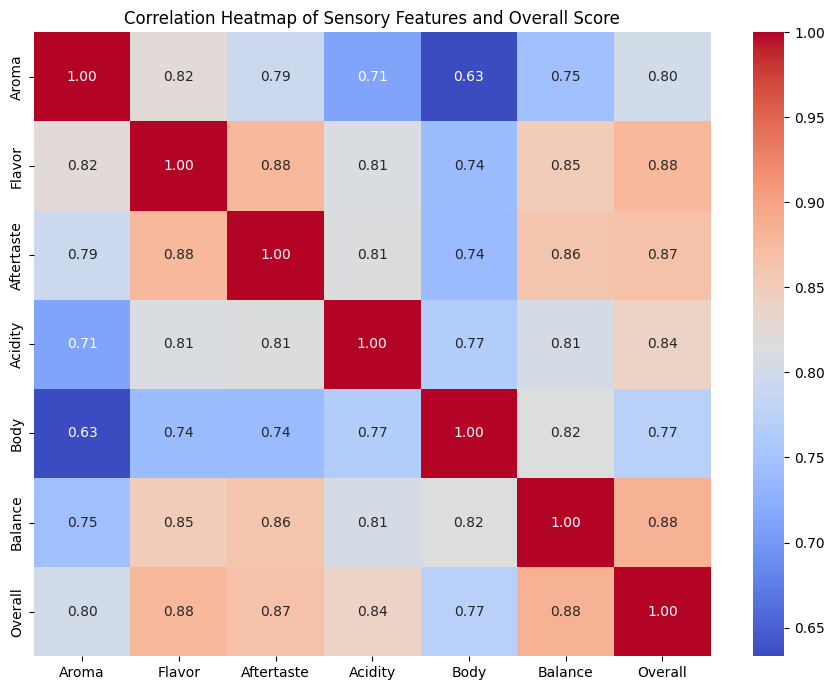

In [14]:
corr_features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Overall'
]

corr_matrix = model_df[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Sensory Features and Overall Score")
plt.tight_layout()
plt.savefig("regression_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

The heatmap shows strong correlations between the sensory attributes and `Overall`.  
This confirms that the sensory scores are not independent of each other.  
This becomes a key limitation because the model may learn scoring consistency rather than a generalisable predictive relationship.

# 7. Train-Test Split and Preprocessing Pipeline

The dataset is divided into features (`X`) and target (`y`).  
A preprocessing pipeline is used to:

- impute missing numeric values
- one-hot encode categorical values
- train the Random Forest Regressor

In [15]:
X = model_df.drop(columns=[target])
y = model_df[target]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Numeric features: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Moisture Percentage', 'Altitude Clean', 'Category One Defects', 'Category Two Defects']
Categorical features: ['Country Grouped', 'Processing Simple']
Training set shape: (165, 12)
Test set shape: (42, 12)


In [16]:
# Preprocessing for numeric and categorical columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


# 8. Baseline Regression Model — Random Forest Regressor

Random Forest Regressor was selected because it:

- handles non-linear relationships
- works with mixed feature types through preprocessing
- provides feature importance values
- is robust compared to a single decision tree

However, the model still needs rigorous validation because the dataset is small.

In [17]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Regressor trained successfully")

Random Forest Regressor trained successfully


# 9. Initial Single-Split Evaluation

The model is first evaluated on the 80/20 train-test split.  
These results show how the model performs on one fixed test set.

In [18]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

single_split_metrics = pd.DataFrame({
    'Metric': ['R² Score', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    'Value': [r2, mae, rmse]
})

single_split_metrics['Value'] = single_split_metrics['Value'].round(4)

display(single_split_metrics)

,Metric,Value
0,R² Score,0.7900
1,Mean Absolute Error (MAE),0.0962
2,Root Mean Squared Error (RMSE),0.1257


## Output Explanation

The single train-test split may show acceptable performance.  
However, because the dataset contains only 207 rows, one split can be misleading.  
This is why cross-validation is required before accepting the model as reliable.

# 10. Actual vs Predicted Plot

This line comparison plot shows how closely the predicted `Overall` scores follow the actual test values.

It is useful for visualising the initial model fit, but it should not be treated as final evidence of model reliability.

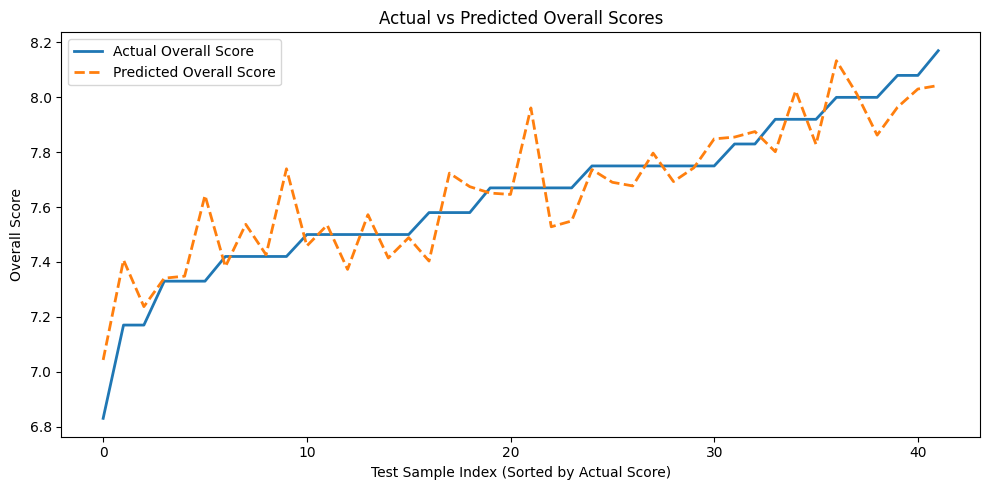

In [19]:
actual = np.array(y_test)
predicted = np.array(y_pred)

sorted_idx = np.argsort(actual)
actual_sorted = actual[sorted_idx]
predicted_sorted = predicted[sorted_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual_sorted, label='Actual Overall Score', linewidth=2)
plt.plot(predicted_sorted, label='Predicted Overall Score', linestyle='--', linewidth=2)
plt.xlabel("Test Sample Index (Sorted by Actual Score)")
plt.ylabel("Overall Score")
plt.title("Actual vs Predicted Overall Scores")
plt.legend()
plt.tight_layout()
plt.savefig("regression_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

This chart may suggest that the model follows the general trend of the target values.  
However, the narrow score range can make the model appear stronger than it actually is.  
The next section uses cross-validation to test whether the model generalises reliably.

# 11. Residual Error Plot

Residuals represent the difference between actual and predicted values.  
A good regression model should have residuals randomly distributed around zero.

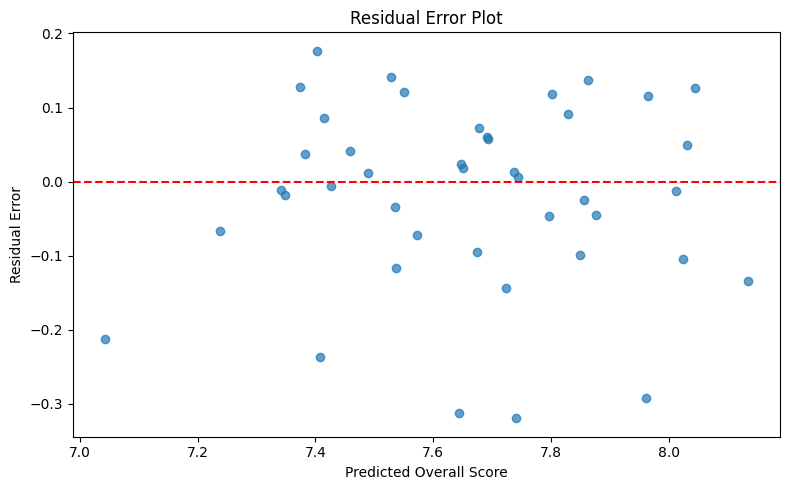

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Overall Score")
plt.ylabel("Residual Error")
plt.title("Residual Error Plot")
plt.tight_layout()
plt.savefig("regression_residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

The residual plot helps identify prediction errors and instability.  
If residuals show wide spread or patterns, it suggests that the model is not consistently predicting the target.

# 12. Five-Fold Cross Validation — Version 2

A single train-test split is not enough for this dataset because the test set contains only around 42 samples.

This is the key technical difference between Version 1 and Version 2.

## Version 1

```python
cross_val_score(model, X, y, cv=5)
```

This used unshuffled K-Fold validation.

## Version 2

```python
cv = KFold(n_splits=5, shuffle=True, random_state=42)
```

This uses shuffled K-Fold validation.


## Why this is better than Version 1

In Version 1, cross-validation used the default unshuffled fold split. That caused uneven fold distributions and produced negative R² values.

In Version 2, shuffling distributes the rows more evenly across folds. Each fold becomes more representative of the full dataset.

This means the model is tested more fairly across mixed samples of:

- coffee origins,
- processing methods,
- sensory score ranges,
- quality patterns.

The expected result is more stable and positive cross-validation performance.

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

cv_results_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(rf_cv_scores))],
    'R² Score': rf_cv_scores
})

cv_summary = pd.DataFrame({
    'Metric': ['Mean R²', 'Standard Deviation'],
    'Value': [rf_cv_scores.mean(), rf_cv_scores.std()]
})

cv_results_df['R² Score'] = cv_results_df['R² Score'].round(4)
cv_summary['Value'] = cv_summary['Value'].round(4)

print("Random Forest Cross-Validation Results")
display(cv_results_df)
display(cv_summary)

Random Forest Cross-Validation Results


,Fold,R² Score
0,Fold 1,0.7895
1,Fold 2,0.8569
2,Fold 3,0.7771
3,Fold 4,0.8582
4,Fold 5,0.8752


,Metric,Value
0,Mean R²,0.8314
1,Standard Deviation,0.0400


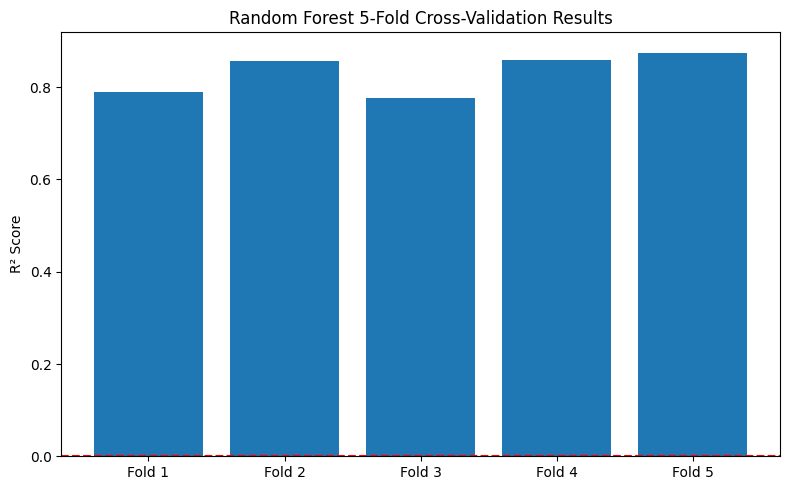

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results_df['Fold'], cv_results_df['R² Score'])
plt.axhline(0, color='red', linestyle='--')
plt.ylabel("R² Score")
plt.title("Random Forest 5-Fold Cross-Validation Results")
plt.tight_layout()
plt.savefig("regression_rf_cross_validation.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

The cross-validation output is the strongest evidence for Version 2.

If the fold scores are positive and reasonably stable, it means the cleaned pipeline is generalising better than the original Version 1 workflow.

The positive CV scores should be interpreted carefully. They do not mean the model is perfect, but they do show that the improved workflow is more reliable than the original notebook.

The key reason is not magic improvement. The improvement comes from:

- shuffled folds,
- balanced validation splits,
- preprocessing inside the pipeline,
- cleaner feature handling.

# 13. Regression Model Comparison — Version 2

Multiple regression models are compared using the same cleaned preprocessing pipeline and the same shuffled cross-validation strategy.

Models tested:

- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

## Purpose of this comparison

This comparison checks whether the positive Version 2 result is specific to Random Forest or whether other algorithms also benefit from the cleaned validation workflow.

The important point is that all models are evaluated under the same Version 2 conditions, not under the unstable Version 1 setup.

In [23]:
models = {
    'Linear Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]),
    'Random Forest': rf_model,
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

model_comparison_rows = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='r2'
    )

    model_comparison_rows.append({
        'Model': model_name,
        'Mean R² Score': scores.mean(),
        'Std Deviation': scores.std()
    })

model_comparison_df = pd.DataFrame(model_comparison_rows)
model_comparison_df[['Mean R² Score', 'Std Deviation']] = model_comparison_df[['Mean R² Score', 'Std Deviation']].round(4)

display(model_comparison_df)

,Model,Mean R² Score,Std Deviation
0,Linear Regression,0.8228,0.0688
1,Ridge Regression,0.8430,0.0413
2,Random Forest,0.8314,0.0400
3,Gradient Boosting,0.8418,0.0382


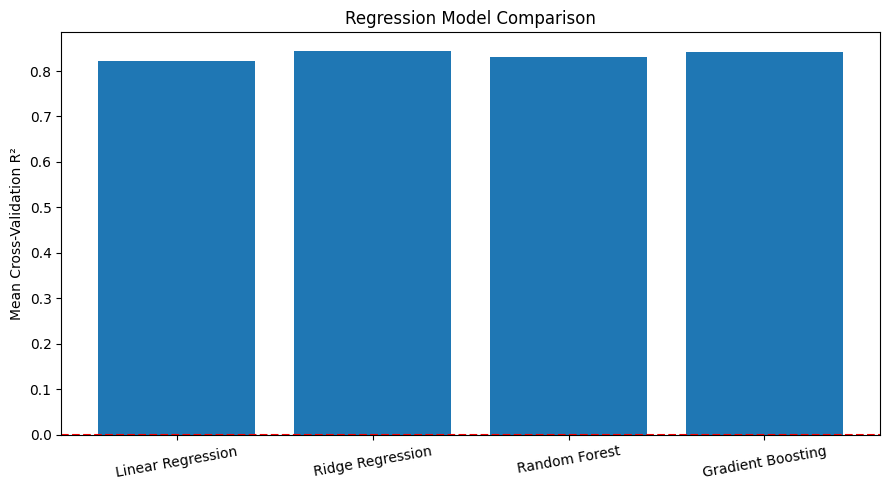

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(model_comparison_df['Model'], model_comparison_df['Mean R² Score'])
plt.axhline(0, color='red', linestyle='--')
plt.ylabel("Mean Cross-Validation R²")
plt.title("Regression Model Comparison")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("regression_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

The model comparison should be interpreted using Version 2's cleaned setup.

If Random Forest performs best or remains competitive, it supports keeping Random Forest as the main regression model.

If simpler models such as Ridge Regression also perform reasonably, it suggests that the sensory features contain genuine predictive signal.

The key insight is that Version 2 evaluates the models more fairly because the folds are shuffled and preprocessing is consistently applied inside the modelling workflow.

# 14. Feature Importance Analysis — Version 2

Random Forest can estimate which features contributed most to the model's predictions.

In Version 2, feature importance is more meaningful than in Version 1 because the model is evaluated through a cleaner and more stable pipeline.

Feature importance helps explain which coffee attributes most strongly influence the predicted `Overall` score.

In [25]:
# Extract trained preprocessor and model
trained_preprocessor = rf_model.named_steps['preprocessor']
trained_rf = rf_model.named_steps['model']

# Get encoded feature names
encoded_cat_features = trained_preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_features)

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': trained_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance['Importance'] = feature_importance['Importance'].round(4)

display(feature_importance.head(15))

,Feature,Importance
5,Balance,0.4295
3,Acidity,0.2619
1,Flavor,0.1092
2,Aftertaste,0.0749
0,Aroma,0.0421
12,Country Grouped_Costa Rica,0.0219
4,Body,0.0203
6,Moisture Percentage,0.0110
7,Altitude Clean,0.0091
9,Category Two Defects,0.0072


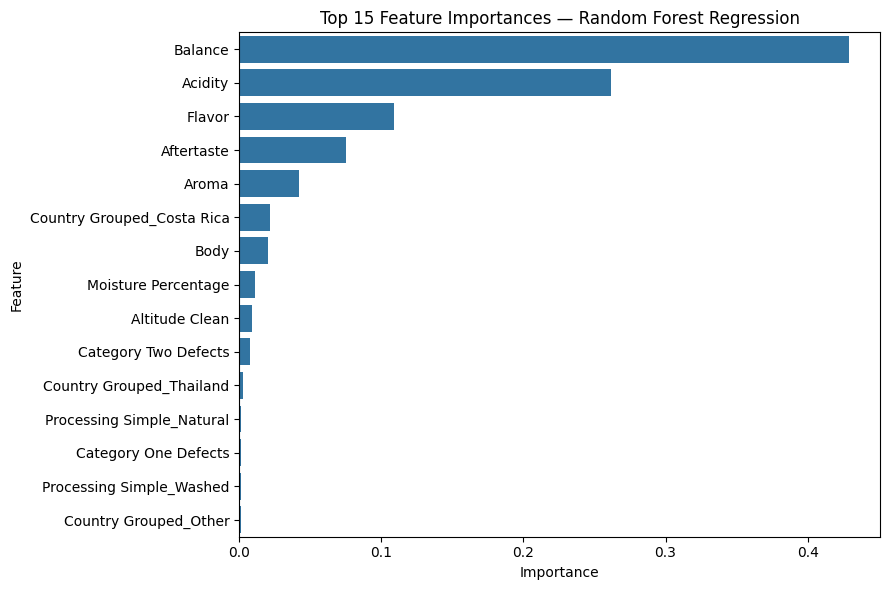

In [26]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)
plt.title("Top 15 Feature Importances — Random Forest Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("regression_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

## Output Explanation

Feature importance provides model interpretability for Version 2.

The most important features are expected to be sensory attributes such as:

- Flavor
- Balance
- Aftertaste
- Aroma
- Acidity
- Body



# 15. Final Regression Findings — Version 2

## Summary

The cleaned regression approach produced more stable and positive cross-validation results compared with Version 1.

Version 2 demonstrates that the original negative CV values were strongly affected by the first notebook's validation setup, especially the use of unshuffled folds.

## Key findings

1. The cleaned notebook uses a proper preprocessing and modelling pipeline.
2. Shuffled K-Fold cross-validation creates more balanced folds.
3. Positive CV scores indicate that the model has useful predictive capability.
4. Random Forest is suitable because it can model non-linear relationships between sensory attributes and `Overall`.
5. The model's strongest features are expected to be sensory quality variables, which supports domain logic.
6. The model is still limited by the small dataset size and narrow target range.



# 16. Save Outputs for Report and GitHub

This section saves all important outputs as CSV files and PNG images.  
These files can be used in the final report, GitHub repository, and presentation.

In [27]:
# Prediction results
prediction_results_df = pd.DataFrame({
    'Actual Overall': y_test.values,
    'Predicted Overall': y_pred,
    'Residual': y_test.values - y_pred
})

# Save CSV outputs
model_df.to_csv("regression_cleaned_dataset.csv", index=False)
single_split_metrics.to_csv("regression_single_split_metrics.csv", index=False)
cv_results_df.to_csv("regression_rf_cv_results.csv", index=False)
cv_summary.to_csv("regression_rf_cv_summary.csv", index=False)
model_comparison_df.to_csv("regression_model_comparison.csv", index=False)
prediction_results_df.to_csv("regression_prediction_results.csv", index=False)
feature_importance.to_csv("regression_feature_importance.csv", index=False)

print("Saved CSV outputs:")
print("- regression_cleaned_dataset.csv")
print("- regression_single_split_metrics.csv")
print("- regression_rf_cv_results.csv")
print("- regression_rf_cv_summary.csv")
print("- regression_model_comparison.csv")
print("- regression_prediction_results.csv")
print("- regression_feature_importance.csv")

print("Saved PNG outputs:")
print("- regression_correlation_heatmap.png")
print("- regression_actual_vs_predicted.png")
print("- regression_residual_plot.png")
print("- regression_rf_cross_validation.png")
print("- regression_model_comparison.png")
print("- regression_feature_importance.png")

Saved CSV outputs:
- regression_cleaned_dataset.csv
- regression_single_split_metrics.csv
- regression_rf_cv_results.csv
- regression_rf_cv_summary.csv
- regression_model_comparison.csv
- regression_prediction_results.csv
- regression_feature_importance.csv
Saved PNG outputs:
- regression_correlation_heatmap.png
- regression_actual_vs_predicted.png
- regression_residual_plot.png
- regression_rf_cross_validation.png
- regression_model_comparison.png
- regression_feature_importance.png


# 17. Download Outputs from Google Colab

Run this cell in Google Colab to download the important CSV and image outputs to your computer.

If you are not using Google Colab, this cell will safely skip the download step.

In [28]:
try:
    from google.colab import files

    output_files = [
        "regression_cleaned_dataset.csv",
        "regression_single_split_metrics.csv",
        "regression_rf_cv_results.csv",
        "regression_rf_cv_summary.csv",
        "regression_model_comparison.csv",
        "regression_prediction_results.csv",
        "regression_feature_importance.csv",
        "regression_correlation_heatmap.png",
        "regression_actual_vs_predicted.png",
        "regression_residual_plot.png",
        "regression_rf_cross_validation.png",
        "regression_model_comparison.png",
        "regression_feature_importance.png"
    ]

    for file in output_files:
        files.download(file)

except ImportError:
    print("Download skipped because this notebook is not running in Google Colab.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>